# Simulasi Model Ising 2D Menggunakan Algoritma Metropolis
## Kasus 3: Fase Paramagnetik (T = 4.0)

Nama : Juan Prayoga

NIM : 01241007

Kelompok : SPX 

## Tujuan

1. Menginisialisasi kisi spin 2D berukuran 20 × 20 menggunakan konfigurasi acak (Hot Start).
2. Menjalankan simulasi Monte Carlo Metropolis sebanyak minimal 200.000 langkah.
3. Menghitung magnetisasi rata-rata sistem secara berkala.
4. Memvisualisasikan keadaan akhir kisi spin dan riwayat magnetisasi.
5. Menganalisis perilaku fisis sistem pada suhu T = 4.0

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

# Parameter simulasi
N = 20
T = 4.0                 #Kasus 3
jumlah_langkah = 200000
interval_pengukuran = 100



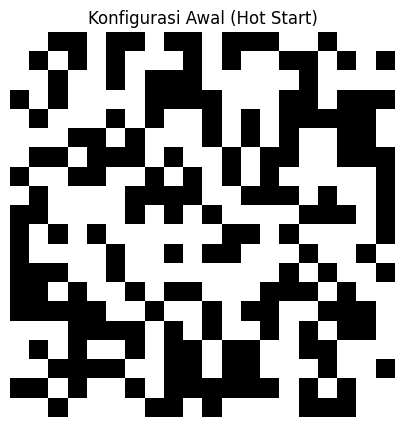

Magnetisasi awal = -0.08


In [2]:
#Menginisialisasi kisi $ N \times N $(dengan N = 20) menggunakan konfigurasi acak (Hot Start) untuk merepresentasikan entropi maksimum sistem.
# Membuat konfigurasi awal spin secara acak
kisi_spin = np.random.choice(
    [-1, 1],
    size=(N, N)
)

plt.figure(figsize=(5, 5))
plt.imshow(
    kisi_spin,
    cmap='binary',
    vmin=-1,
    vmax=1
)
plt.title('Konfigurasi Awal (Hot Start)')
plt.axis('off')
plt.show()

print("Magnetisasi awal =", np.mean(kisi_spin))

In [3]:
def langkah_metropolis(kisi_spin, T):

    # Memilih satu spin secara acak
    i = random.randint(0, N - 1)
    j = random.randint(0, N - 1)

    # Menghitung jumlah empat tetangga
    jumlah_tetangga = (
        kisi_spin[(i + 1) % N, j]
        + kisi_spin[(i - 1) % N, j]
        + kisi_spin[i, (j + 1) % N]
        + kisi_spin[i, (j - 1) % N]
    )

    # Menghitung perubahan energi lokal
    delta_E = (
        2
        * kisi_spin[i, j]
        * jumlah_tetangga
    )

    # Aturan Metropolis
    if (
        delta_E <= 0
        or random.random() < np.exp(-delta_E / T)
    ):
        kisi_spin[i, j] *= -1

    return kisi_spin

In [4]:
#Menjalankan minimal 200.000 langkah Monte Carlo untuk memastikan sistem telah mencapai kesetimbangan termal sebelum pengumpulan data makrostate dilakukan.
riwayat_M = []

for langkah in range(jumlah_langkah):

    # Melakukan satu percobaan flip spin
    kisi_spin = langkah_metropolis(
        kisi_spin,
        T
    )

    # Menghitung magnetisasi setiap 100 langkah
    if langkah % interval_pengukuran == 0:
        M = np.mean(kisi_spin)
        riwayat_M.append(M)

print("Magnetisasi akhir =", np.mean(kisi_spin))

Magnetisasi akhir = 0.17


In [ ]:

#Menampilkan visualisasi keadaan akhir kisi spin menggunakan peta warna biner (cmap='binary') berdampingan dengan kurva riwayat magnetisasi rata-rata sepanjang fungsi waktu simulasi.
fig, grafik = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Konfigurasi akhir spin
grafik[0].imshow(
    kisi_spin,
    cmap='binary',
    vmin=-1,
    vmax=1
)
grafik[0].set_title(
    f'Konfigurasi Akhir Spin (T = {T})'
)
grafik[0].axis('off')

# Riwayat magnetisasi
grafik[1].plot(riwayat_M)
grafik[1].set_title('Riwayat Magnetisasi')
grafik[1].set_xlabel(
    f'Langkah Monte Carlo (setiap {interval_pengukuran} langkah)'
)
grafik[1].set_ylabel(
    'Magnetisasi Rata-rata (M)'
)
grafik[1].set_ylim(-1.1, 1.1)
print(np.mean(kisi_spin))

plt.tight_layout()
plt.show()

0.17
